<a href="https://colab.research.google.com/github/varchu04/smart-waste-detection/blob/main/04_data_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 4 — Data Augmentation

## Objectives

- Understand why data augmentation is useful
- Apply realistic transformations to training images
- Compare original and augmented images
- Build an efficient image data pipeline
- Prepare the dataset for model training

In [9]:
import os
import kagglehub

# Download/access dataset
dataset_path = kagglehub.dataset_download(
    "techsash/waste-classification-data"
)

# Define dataset paths
train_path = os.path.join(
    dataset_path,
    "DATASET",
    "TRAIN"
)

test_path = os.path.join(
    dataset_path,
    "DATASET",
    "TEST"
)

print("Dataset:", dataset_path)
print("Training:", train_path)
print("Testing:", test_path)

print("Training classes:", os.listdir(train_path))
print("Testing classes:", os.listdir(test_path))

Using Colab cache for faster access to the 'waste-classification-data' dataset.
Dataset: /kaggle/input/waste-classification-data
Training: /kaggle/input/waste-classification-data/DATASET/TRAIN
Testing: /kaggle/input/waste-classification-data/DATASET/TEST
Training classes: ['R', 'O']
Testing classes: ['R', 'O']


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

print("Data augmentation pipeline created.")

Data augmentation pipeline created.


In [11]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=True
)

Found 22564 images belonging to 2 classes.


In [12]:
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 2513 images belonging to 2 classes.


In [13]:
images, labels = next(train_generator)

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

print("Pixel range:",
      images.min(), "to", images.max())

print("Labels:", labels[:10])

Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)
Pixel range: 0.0 to 1.0
Labels: [0. 0. 1. 0. 1. 1. 1. 0. 1. 0.]


In [14]:
print("Class mapping:")
print(train_generator.class_indices)

Class mapping:
{'O': 0, 'R': 1}


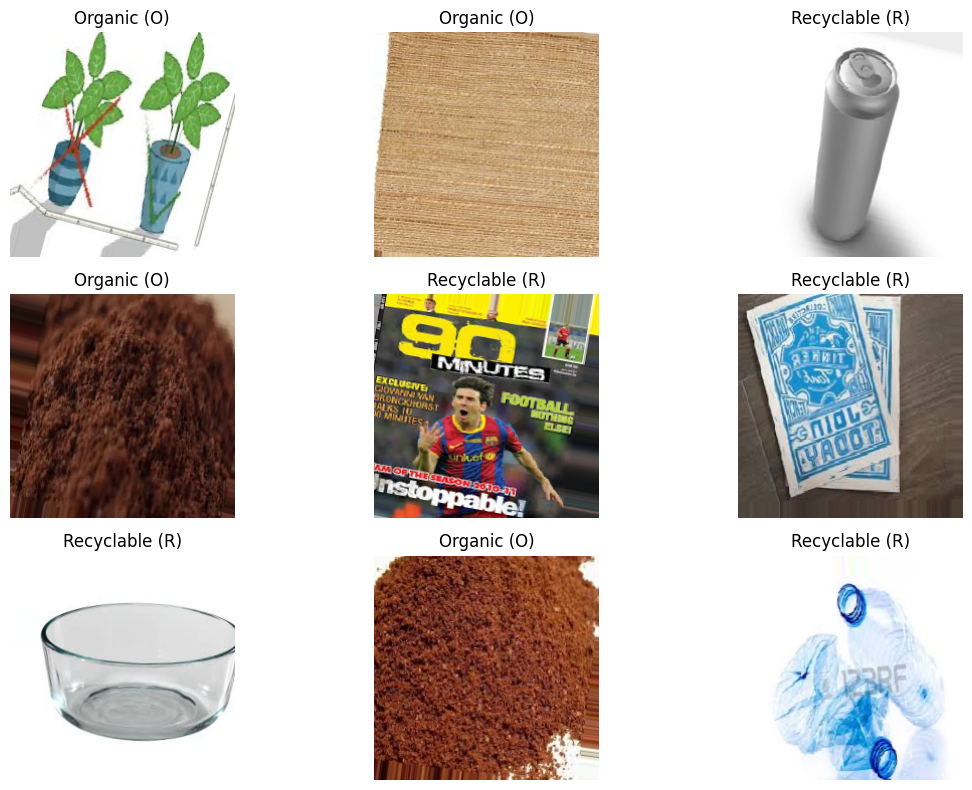

In [15]:
plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    plt.imshow(images[i])

    label = "Organic (O)" if labels[i] == 0 else "Recyclable (R)"
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Data Augmentation Validation

The training data augmentation pipeline was successfully applied to sample images.

The pipeline performs random rotation, horizontal shifting, vertical shifting, zooming, and horizontal flipping while preserving the original waste category. Pixel values are normalized to the range 0–1 and images are resized to 224 × 224 pixels.

The visualization confirms that augmented images remain visually meaningful and suitable for model training.
